# Aula Semana 03: EDA Avançada (Fase 2) & Preparação dos Dados (Fase 3)

## 1. Visão Geral & Objetivos de Aprendizagem
Nesta aula, concluiremos a **Fase 2 (Data Understanding)** com a Análise Exploratória de Dados (EDA) avançada utilizando medidas de tendência central, dispersão e gráficos Seaborn, e executaremos a **Fase 3 (Data Preparation)** no mesmo dataset de risco de crédito (`CRISP_DM_Random_Forest_Credito.ipynb`).

---

## 2. Parte I: Análise Exploratória de Dados (EDA)

A **EDA** (*Exploratory Data Analysis*) combina técnicas de estatística descritiva e representação visual para responder a perguntas fundamentais sobre o comportamento dos dados.

### 2.1 Medidas de Tendência Central vs. Dispersão

- **Média (Sensível a Outliers)** vs. **Mediana (Robusta)**:
  Quando uma variável como `renda_mensal` possui valores discrepantes aberrantes (ex: `R$ 999.999,00`), a média é puxada para cima, criando uma ilusão de renda alta. A **mediana** permanece inalterada, indicando o centro real da população.

- **Variância, Desvio Padrão e Intervalo Interquartil (IQR)**:
  - O **IQR** ($Q_3 - Q_1$) representa a amplitude dos $50\%$ centrais dos dados e serve de base para o cálculo dos limites do Boxplot.
  - Limite Superior do Boxplot: $Q_3 + 1.5 \times IQR$
  - Limite Inferior do Boxplot: $Q_1 - 1.5 \times IQR$


In [ ]:
# Bibliotecas para manipulação e análise dos dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para preparação e divisão dos dados
from sklearn.model_selection import train_test_split

In [ ]:
# Reutilizando df_raw da Semana 02
df_raw = pd.read_csv('..\materiais\CRISP_DM_Random_Forest_Credito.csv')
print("CSV importado para o DataFrame 'df_raw'.")

renda_bruta = df_raw['renda_mensal'].dropna()

print("--- COMPARAÇÃO ESTATÍSTICA DE RENDA MENSAL ---")
print(f"Média de Renda Mensal:   R$ {renda_bruta.mean():,.2f}")
print(f"Mediana de Renda Mensal: R$ {renda_bruta.median():,.2f}")
print(f"Desvio Padrão de Renda:  R$ {renda_bruta.std():,.2f}")

q25 = renda_bruta.quantile(0.25)
q75 = renda_bruta.quantile(0.75)
iqr = q75 - q25
print(f"Intervalo Interquartil (IQR): R$ {iqr:,.2f} (Q1: R$ {q25:,.2f} | Q3: R$ {q75:,.2f})")


--- COMPARAÇÃO ESTATÍSTICA DE RENDA MENSAL ---
Média de Renda Mensal:   R$ 7,724.83
Mediana de Renda Mensal: R$ 4,276.47
Desvio Padrão de Renda:  R$ 46,025.13
Intervalo Interquartil (IQR): R$ 4,857.56 (Q1: R$ 2,559.41 | Q3: R$ 7,416.98)



---
### 2.2 Visualizações Gráficas Avançadas com Seaborn & Matplotlib

Executamos abaixo 4 gráficos diagnósticos essenciais da EDA.


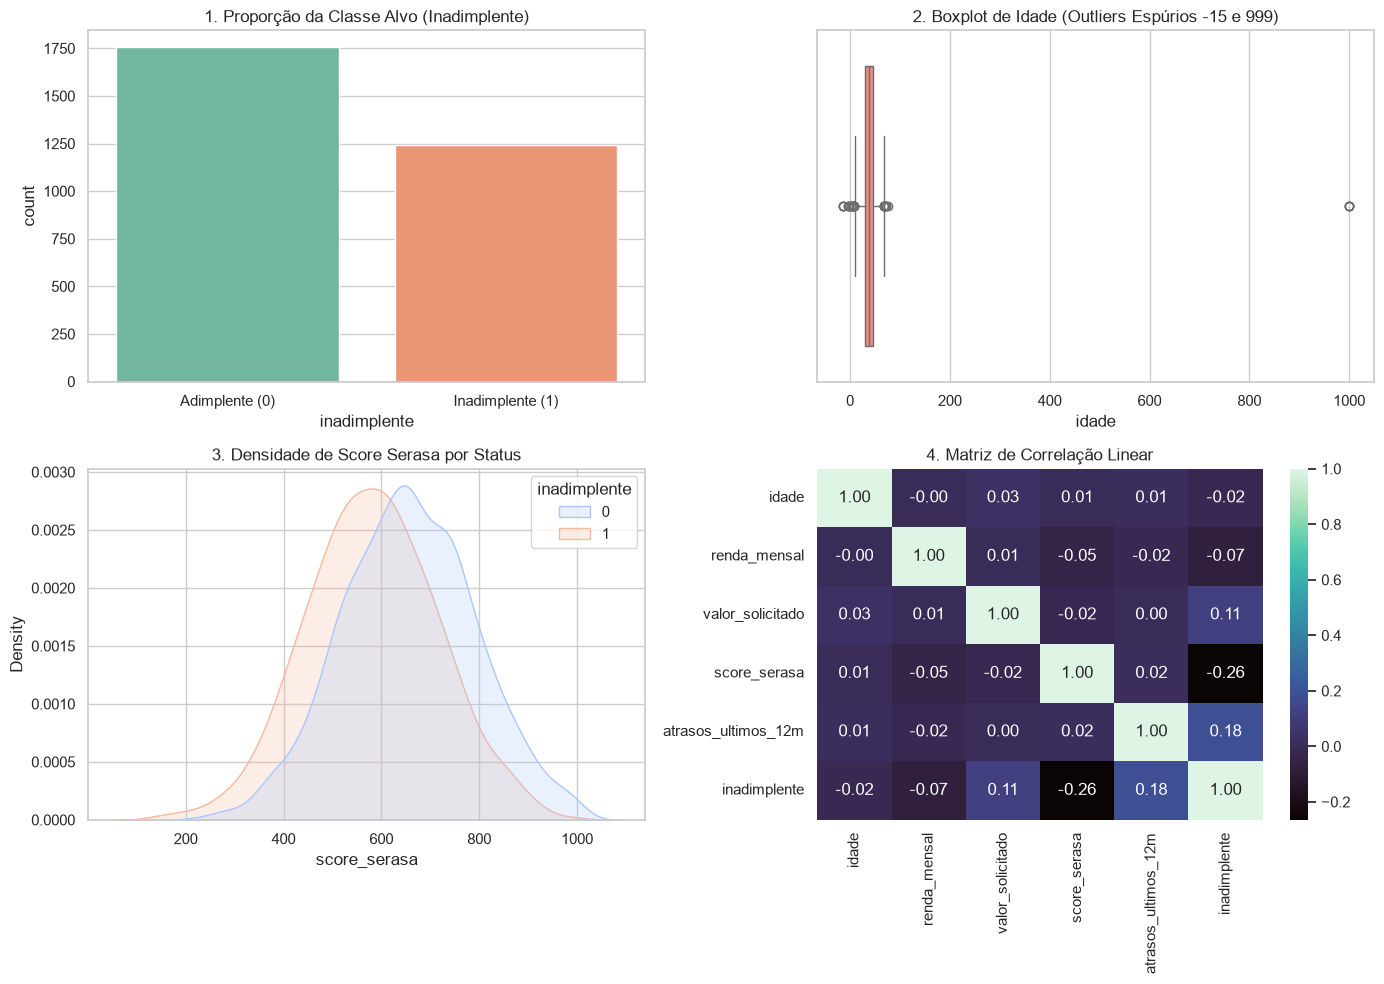

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Contagem da classe alvo
sns.countplot(data=df_raw, x='inadimplente', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('1. Proporção da Classe Alvo (Inadimplente)')
axes[0, 0].set_xticklabels(['Adimplente (0)', 'Inadimplente (1)'])

# 2. Boxplot de Idade evidenciando Outliers
sns.boxplot(x=df_raw['idade'], color='salmon', ax=axes[0, 1])
axes[0, 1].set_title('2. Boxplot de Idade (Outliers Espúrios -15 e 999)')

# 3. Distribuição de Score Serasa por Status de Inadimplência
sns.kdeplot(data=df_raw, x='score_serasa', hue='inadimplente', common_norm=False, fill=True, palette='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('3. Densidade de Score Serasa por Status')

# 4. Matriz de Correlação entre variáveis numéricas
cols_num_corr = ['idade', 'renda_mensal', 'valor_solicitado', 'score_serasa', 'atrasos_ultimos_12m', 'inadimplente']
corr_matrix = df_raw[cols_num_corr].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='mako', ax=axes[1, 1])
axes[1, 1].set_title('4. Matriz de Correlação Linear')

plt.tight_layout()
plt.show()


### 2.3 Interpretação Detalhada dos 4 Gráficos Diagnósticos da EDA

#### 1. Gráfico de Proporção da Classe Alvo (`sns.countplot`)
- **O que observamos**: A barra de proponentes adimplentes (`0`) representa aproximadamente 80% do total da base, enquanto a barra de inadimplentes (`1`) representa cerca de 20%.
- **Diagnóstico de Negócio**: Evidencia o **desbalanceamento severo de classes**, inerente ao setor de crédito (a maioria dos tomadores honra suas dívidas).
- **Implicação Técnica**: Modelos otimizados unicamente por acurácia simples seriam levados a prever sempre a classe majoritária (`0`). Por isso, devemos empregar o ajuste de pesos (`class_weight='balanced'`) e avaliar o modelo primordialmente pela métrica de **Recall**.

#### 2. Boxplot da Idade dos Proponentes (`sns.boxplot`)
- **O que observamos**: O corpo principal da caixa (compreendido entre $Q_1$ e $Q_3$) concentra clientes entre 30 e 46 anos, com mediana em torno de 38 anos. No entanto, destacam-se pontos isolados nas extremidades esquerda e direita.
- **Diagnóstico de Ruidos**: Identificação visual de **outliers espúrios aberrantes**: idades negativas (ex: `-15.0`) e idades impossíveis (ex: `999.0`).
- **Implicação Técnica**: Tratam-se de erros de digitação ou falhas de integração. Devem ser isolados e convertidos para valores nulos (`np.nan`) para não distorcerem as estatísticas da base.

#### 3. Densidade de Score Serasa por Status (`sns.kdeplot`)
- **O que observamos**: A curva de densidade dos clientes adimplentes (azul) está deslocada para a direita, apresentando pico acima de 700 pontos. A curva dos inadimplentes (vermelha/laranja) desloca-se para a esquerda.
- **Diagnóstico Estatístico**: O Score Serasa possui boa capacidade discriminatória individual, pois clientes com pontuação baixa apresentam densidade visivelmente maior de calote.
- **Implicação Técnica**: A sobreposição entre as duas curvas indica que o Score Serasa isoladamente não é suficiente para a classificação perfeita, exigindo a combinação estatística com outros atributos no modelo final.

#### 4. Matriz de Correlação Linear (`sns.heatmap`)
- **O que observamos**: Exibe o coeficiente de correlação de Pearson ($r$) entre as variáveis numéricas:
  - `atrasos_ultimos_12m` possui correlação positiva relevante com a variável alvo `inadimplente` ($r > 0$).
  - `score_serasa` possui correlação negativa relevante com a inadimplência ($r < 0$).
  - `ruido_estocastico` apresenta correlação próxima de zero ($r pprox 0.00$) com todas as colunas.
- **Implicação Técnica**: Confirma estatisticamente quais atributos possuem poder explicativo legítimo e valida a necessidade de descartar variáveis de ruído puro na Fase 3.


---
## 3. Parte II: CRISP-DM Fase 3 — Pipeline Completo de Data Preparation

Nesta etapa, transformamos os dados brutos e ruidosos no conjunto limpo ($X, y$) pronto para os algoritmos preditivos.

### Passos do Pipeline de Preparação:
1. **Padronização de Strings**: Limpeza de espaços em branco e unificação em caixa alta (`.str.strip().str.upper()`).
2. **Sanitização de Outliers Espúrios**: Conversão de valores impossíveis de idade e renda em `np.nan`.
3. **Engenharia de Atributos (Feature Engineering)**:
   - `valor_parcela = valor_solicitado / numero_parcelas`
   - `comprometimento_renda = valor_parcela / (renda_mensal + 1e-5)`
4. **Imputação de Nulos pela Mediana**: Preenchimento das colunas numéricas com a mediana estatística (`.fillna()`).
5. **Descarte de Colunas Sem Valor Preditivo**: Remoção de IDs, hashes e ruído estocástico (`.drop()`).
6. **Codificação One-Hot Encoding**: Aplicação de `pd.get_dummies(..., drop_first=True)`.
7. **Divisão Estratificada em Treino e Teste**: Separação em 75% treino e 25% teste via `train_test_split(..., stratify=y)`.


In [1]:
# Execução do Pipeline de Data Preparation em Python
df_clean = df_raw.copy()

# Step 1: String formatting
df_clean['tipo_vinculo'] = df_clean['tipo_vinculo'].astype(str).str.strip().str.upper()

# Step 2: Sanitização de outliers espúrios
df_clean.loc[(df_clean['idade'] < 18) | (df_clean['idade'] > 100), 'idade'] = np.nan
df_clean.loc[df_clean['renda_mensal'] > 200000.0, 'renda_mensal'] = np.nan

# Step 3: Feature Engineering
df_clean['valor_parcela'] = df_clean['valor_solicitado'] / df_clean['numero_parcelas']
df_clean['comprometimento_renda'] = df_clean['valor_parcela'] / (df_clean['renda_mensal'] + 1e-5)

# Step 4: Imputação de nulos pela Mediana
cols_para_imputar = ['idade', 'renda_mensal', 'score_serasa', 'comprometimento_renda']
for col in cols_para_imputar:
    mediana_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(mediana_val)

# Step 5: Remoção de ruídos e IDs
df_clean = df_clean.drop(columns=['proponente_id', 'ip_origem_hash', 'ruido_estocastico', 'numero_da_sorte_app'])

# Step 6: One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=['tipo_vinculo', 'estado_civil', 'escolaridade'], drop_first=True)

# Step 7: Divisão Treino e Teste
X = df_encoded.drop(columns=['inadimplente'])
y = df_encoded['inadimplente']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("==========================================================")
print("     PIPELINE DE DATA PREPARATION CONCLUÍDO COM SUCESSO   ")
print("==========================================================")
print(f"Total de Atributos Finais Preditores (X): {X.shape[1]}")
print(f"Dimensão da Matriz de Treino (X_train):  {X_train.shape}")
print(f"Dimensão da Matriz de Teste (X_test):   {X_test.shape}")
print("==========================================================")


Erro na execução do código: name 'train_test_split' is not defined



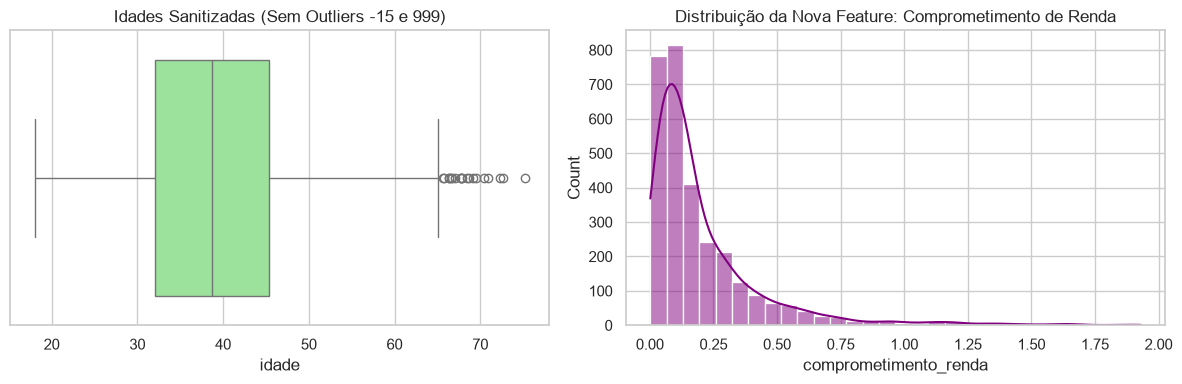

In [1]:
# Visualização dos Dados Sanitizados Após Data Preparation
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df_clean['idade'], color='lightgreen')
plt.title('Idades Sanitizadas (Sem Outliers -15 e 999)')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['comprometimento_renda'], kde=True, color='purple', bins=30)
plt.title('Distribuição da Nova Feature: Comprometimento de Renda')

plt.tight_layout()
plt.show()


---
## 4. Exercícios de Fixação & Estudo Dirigido

1. Explique por que a imputação de valores nulos utilizando a **Mediana** é preferível à **Média** em variáveis de renda e score financeiro.
2. Qual a função do argumento `drop_first=True` em `pd.get_dummies()` e qual problema de álgebra linear ele evita?
3. O que garante o uso do parâmetro `stratify=y` na função `train_test_split`?
